In [1]:

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from dataclasses import dataclass
from typing import Optional, Dict, Any, List, Tuple

import numpy as np
import pandas as pd
import cvxpy as cp
import matplotlib.pyplot as plt

# Try project imports first.
# If your package is installed / notebook is run from project root, these should work directly.
from agentic_energy.schemas import BatteryParams, DayInputs, SolveRequest, SolveResponse
from agentic_energy.milp.milp_mcp_server import records_to_arrays, solve_daily_milp
from agentic_energy.milp.robust_baselines import (
    estimate_bias, apply_bias, residual_matrix, sample_scenarios, 
    solve_bias_corrected_deterministic,
    solve_scenario_expected_cost,
    solve_scenario_cvar 
)  
from agentic_energy.data_loader import EnergyDataLoader, BatteryDataLoader
from agentic_energy.schemas import BatteryParams, DayInputs, EnergyDataRecord, SolveFromRecordsRequest

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True


Available LLM providers: ['gemini', 'openai', 'ollama']


In [2]:
REGION="ITALY"
data_version = "forecast"
forecast_type = "RF"
duration_hours=4
capacity=43.13
soc_init=0.5
soc_min=0.0
soc_max=1.0
eta_c = 0.80
eta_d = 0.80
soc_target=0.5

history_start_date="2018-01-01"
history_end_date="2018-12-31"
test_start_date="2019-12-01"
test_end_date="2019-12-01"

In [3]:
history_forecast_obj = EnergyDataLoader(region = REGION, data_version=data_version, forecast_type=forecast_type)
history_forecast_data = history_forecast_obj.load_region_data()
history_forecast = await history_forecast_obj.get_filtered_data(history_start_date, history_end_date)

test_forecast_obj = EnergyDataLoader(region = REGION, data_version=data_version, forecast_type=forecast_type)
test_forecast_data = test_forecast_obj.load_region_data()
test_forecast = await test_forecast_obj.get_filtered_data(test_start_date, test_end_date)

2026-04-14 22:43:12.396 | DEBUG    | agentics.core.agentics:from_csv:307 - Importing Agentics of type EnergyDataRecord from CSV /Users/millendroy/Projects/Agentic_Energy/Agentics_for_EnergyArbitrage_Battery/agentic_energy/agentic_energy/data/Italy_data_forecast_RF.csv
2026-04-14 22:43:12.618 | DEBUG    | agentics.core.agentics:from_csv:307 - Importing Agentics of type EnergyDataRecord from CSV /Users/millendroy/Projects/Agentic_Energy/Agentics_for_EnergyArbitrage_Battery/agentic_energy/agentic_energy/data/Italy_data_forecast_RF.csv


In [4]:
history_actual_obj = EnergyDataLoader(region=REGION, data_version = "actual")
history_actual_data = history_actual_obj.load_region_data()
history_actual = await history_actual_obj.get_filtered_data(start_date=history_start_date, end_date=history_end_date)

test_actual_obj = EnergyDataLoader(region=REGION, data_version = "actual")
test_actual_data = test_actual_obj.load_region_data()
test_actual = await test_actual_obj.get_filtered_data(start_date=test_start_date, end_date=test_end_date)

2026-04-14 22:43:12.703 | DEBUG    | agentics.core.agentics:from_csv:307 - Importing Agentics of type EnergyDataRecord from CSV /Users/millendroy/Projects/Agentic_Energy/Agentics_for_EnergyArbitrage_Battery/agentic_energy/agentic_energy/data/Italy_data_actual.csv
2026-04-14 22:43:12.784 | DEBUG    | agentics.core.agentics:from_csv:307 - Importing Agentics of type EnergyDataRecord from CSV /Users/millendroy/Projects/Agentic_Energy/Agentics_for_EnergyArbitrage_Battery/agentic_energy/agentic_energy/data/Italy_data_actual.csv


In [5]:
from datetime import datetime, timedelta
stats= await EnergyDataLoader.get_summary_stats_from_ag(history_actual_data)
timedelta = datetime.strptime(stats.states[0].date_range.end, "%Y-%m-%d %H:%M:%S") - datetime.strptime(stats.states[0].date_range.start, "%Y-%m-%d %H:%M:%S")
days = timedelta.days + 1
days

365

In [6]:
def keep_full_days(records):
    """
    Filters the input records to keep only those that belong to full days 
    (i.e., days with 24 hourly records). Returns the filtered records and the list of valid dates.
    """
    rows = [r for r in records if r.prices is not None and r.consumption is not None]
    rows = sorted(rows, key=lambda r: r.timestamps)

    grouped = {}
    for r in rows:
        d = pd.to_datetime(r.timestamps).date()
        grouped.setdefault(d, []).append(r)

    full_day_records = []
    valid_dates = []

    for d in sorted(grouped.keys()):
        day_rows = sorted(grouped[d], key=lambda r: r.timestamps)
        if len(day_rows) == 24:
            full_day_records.extend(day_rows)
            valid_dates.append(d)

    return full_day_records, valid_dates


history_forecast_records, history_dates = keep_full_days(history_forecast.states)
history_actual_records, _ = keep_full_days(history_actual.states)

test_forecast_records, test_dates = keep_full_days(test_forecast.states)
test_actual_records, _ = keep_full_days(test_actual.states)

print(len(history_dates), len(test_dates))
print(len(history_forecast_records), len(history_actual_records))
print(len(test_forecast_records), len(test_actual_records))

364 1
8736 8736
24 24


In [7]:
# capacity = 43.13  # MWh
batterydetails = BatteryParams(
    capacity_MWh=capacity,   # 4-hour energy at 100 MW power: good for diurnal spreads
    soc_init=soc_init,        # neutral start
    soc_min=soc_min,         # keep 10% buffer for longevity + contingency
    soc_max=soc_max,         # avoid top-of-charge stress
    cmax_MW=capacity/duration_hours,        # 4-hour duration (capacity/4)
    dmax_MW=capacity/duration_hours,        # symmetric charge/discharge
    eta_c=eta_c,           # ~92% round-trip when paired with eta_d
    eta_d=eta_d,
    soc_target=soc_target       # keep headroom to buy when prices dip; adjust by time-of-day policy
)
# batterydetails = batt.compute_battery_params()
print(batterydetails)

capacity_MWh=43.13 soc_init=0.5 soc_min=0.0 soc_max=1.0 cmax_MW=10.7825 dmax_MW=10.7825 eta_c=0.8 eta_d=0.8 soc_target=0.5


In [8]:
price_actual_hist = []
price_forecast_hist = []
demand_actual_hist = []
demand_forecast_hist = []

for i in range(len(history_forecast_records) // 24):
    forecast_prices, forecast_demand = records_to_arrays(
        history_forecast_records[i*24:(i+1)*24]
    )
    actual_prices, actual_demand = records_to_arrays(
        history_actual_records[i*24:(i+1)*24]
    )

    price_forecast_hist.append(forecast_prices)
    demand_forecast_hist.append(forecast_demand)
    price_actual_hist.append(actual_prices)
    demand_actual_hist.append(actual_demand)

price_actual_hist = np.array(price_actual_hist, dtype=float)
price_forecast_hist = np.array(price_forecast_hist, dtype=float)
demand_actual_hist = np.array(demand_actual_hist, dtype=float)
demand_forecast_hist = np.array(demand_forecast_hist, dtype=float)

print(price_actual_hist.shape)
print(price_forecast_hist.shape)
print(demand_actual_hist.shape)
print(demand_forecast_hist.shape)

(364, 24)
(364, 24)
(364, 24)
(364, 24)


In [9]:
price_bias = estimate_bias(price_actual_hist, price_forecast_hist)
demand_bias = estimate_bias(demand_actual_hist, demand_forecast_hist)

price_residuals = residual_matrix(price_actual_hist, price_forecast_hist, bias_correct=True)
demand_residuals = residual_matrix(demand_actual_hist, demand_forecast_hist, bias_correct=True)

print(price_bias.shape, demand_bias.shape)
print(price_residuals.shape, demand_residuals.shape)

(24,) (24,)
(364, 24) (364, 24)


In [10]:
results_bias_det = []
day_info_bias_det = []
decision_list_bias_det = []
soc_list_bias_det = []

for i in range(len(test_forecast_records) // 24):
    print(f"Solving day {i+1} of {len(test_forecast_records)//24}")

    forecast_prices, forecast_demand = records_to_arrays(
        test_forecast_records[i*24:(i+1)*24]
    )
    actual_prices, actual_demand = records_to_arrays(
        test_actual_records[i*24:(i+1)*24]
    )

    forecast_prices = np.asarray(forecast_prices, dtype=float)
    forecast_demand = np.asarray(forecast_demand, dtype=float)
    actual_prices = np.asarray(actual_prices, dtype=float)
    actual_demand = np.asarray(actual_demand, dtype=float)

    # -----------------------------
    # 1) Bias-corrected deterministic
    # -----------------------------
    res_bias_det = solve_bias_corrected_deterministic(
        batt=batterydetails,
        price_forecast_next=forecast_prices,
        demand_forecast_next=forecast_demand,
        price_bias=price_bias,
        demand_bias=demand_bias,
        solver=None,
        solver_opts=None,
    )

    corrected_prices = apply_bias(forecast_prices, price_bias)
    corrected_demand = apply_bias(forecast_demand, demand_bias)

    day_bias_det = DayInputs(
        prices_buy=actual_prices.tolist(),
        demand_MW=actual_demand.tolist(),
        prices_sell=actual_prices.tolist(),
        allow_export=True,
        dt_hours=1.0,
        prices_buy_forecast=corrected_prices.tolist(),
        demand_MW_forecast=corrected_demand.tolist(),
        prices_sell_forecast=corrected_prices.tolist(),
    )

    results_bias_det.append(res_bias_det)
    day_info_bias_det.append(day_bias_det)
    decision_list_bias_det += res_bias_det.decision
    soc_list_bias_det += res_bias_det.soc[:-1]

Solving day 1 of 1
Set parameter WLSAccessID


[04/14/26 22:43:15] INFO     Set parameter WLSAccessID                                           ]8;id=302606;file:///Users/millendroy/anaconda3/envs/agentics/lib/python3.11/site-packages/cvxpy/reductions/solvers/qp_solvers/gurobi_qpif.py\gurobi_qpif.py]8;;\:]8;id=394633;file:///Users/millendroy/anaconda3/envs/agentics/lib/python3.11/site-packages/cvxpy/reductions/solvers/qp_solvers/gurobi_qpif.py#160\160]8;;\

Set parameter WLSSecret


                    INFO     Set parameter WLSSecret                                             ]8;id=612449;file:///Users/millendroy/anaconda3/envs/agentics/lib/python3.11/site-packages/cvxpy/reductions/solvers/qp_solvers/gurobi_qpif.py\gurobi_qpif.py]8;;\:]8;id=279825;file:///Users/millendroy/anaconda3/envs/agentics/lib/python3.11/site-packages/cvxpy/reductions/solvers/qp_solvers/gurobi_qpif.py#160\160]8;;\

Set parameter LicenseID to value 2718037


                    INFO     Set parameter LicenseID to value 2718037                            ]8;id=599333;file:///Users/millendroy/anaconda3/envs/agentics/lib/python3.11/site-packages/cvxpy/reductions/solvers/qp_solvers/gurobi_qpif.py\gurobi_qpif.py]8;;\:]8;id=612118;file:///Users/millendroy/anaconda3/envs/agentics/lib/python3.11/site-packages/cvxpy/reductions/solvers/qp_solvers/gurobi_qpif.py#160\160]8;;\

Academic license 2718037 - for non-commercial use only - registered to mi___@columbia.edu


                    INFO     Academic license 2718037 - for non-commercial use only - registered ]8;id=426796;file:///Users/millendroy/anaconda3/envs/agentics/lib/python3.11/site-packages/cvxpy/reductions/solvers/qp_solvers/gurobi_qpif.py\gurobi_qpif.py]8;;\:]8;id=575600;file:///Users/millendroy/anaconda3/envs/agentics/lib/python3.11/site-packages/cvxpy/reductions/solvers/qp_solvers/gurobi_qpif.py#160\160]8;;\
                             to mi___@columbia.edu                                                                 

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


def plot_prices_and_soc(
    day_info,
    result,
    batterydetails,
    price_bias=None,
    day_idx=0,
    title="Prices vs State of Charge (SoC) Over Time",
):
    """
    Plot actual prices, forecast prices, optional bias-corrected prices,
    and SoC for a selected day.

    Parameters
    ----------
    day_info : list[DayInputs]
    result : list[SolveResponse]
    batterydetails : BatteryParams
    price_bias : np.ndarray or None
        If provided, plots bias-corrected prices too.
    day_idx : int
        Day index to plot.
    title : str
        Plot title.
    """
    prices_actual = np.array(day_info[day_idx].prices_buy, dtype=float)
    prices_forecast = np.array(day_info[day_idx].prices_buy_forecast, dtype=float)
    soc = np.array(result[day_idx].soc[1:], dtype=float) * batterydetails.capacity_MWh

    hours = np.arange(len(prices_actual))

    fig, ax1 = plt.subplots(figsize=(14, 6))

    # Primary axis: prices
    ax1.plot(hours, prices_actual, '-b', label='Actual Prices')
    ax1.plot(hours, prices_forecast, linestyle='--', color='orange', label='Forecast Prices')
    
    if price_bias is not None:
        prices_bias_corrected = apply_bias(prices_forecast, price_bias)
        ax1.plot(hours, prices_bias_corrected, '-.r', label='Bias-Corrected Prices')

    ax1.set_xlabel('Hour')
    ax1.set_ylabel('Prices ($/MWh)', color='b')
    ax1.tick_params(axis='y', labelcolor='b')

    # Secondary axis: SoC
    ax2 = ax1.twinx()
    ax2.plot(
        hours,
        soc,
        '-og',
        label='State of Charge (MWh)',
        linewidth=2,
        markersize=6,
    )
    ax2.set_ylabel('State of Charge (MWh)', color='g')
    ax2.tick_params(axis='y', labelcolor='g')

    # Legend
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='best', frameon=False)

    plt.title(title)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

def build_eval_df(
    day_info,
    result,
    batterydetails,
    price_bias=None,
    demand_bias=None,
    method_name="method",
    dt_hours=1.0,
):
    """
    Build an hour-level dataframe by stacking all days together.

    Parameters
    ----------
    day_info : list[DayInputs]
    result : list[SolveResponse]
    batterydetails : BatteryParams
    price_bias : np.ndarray or None
    demand_bias : np.ndarray or None
    method_name : str
        Name of the algorithm/method.
    dt_hours : float

    Returns
    -------
    pd.DataFrame
    """
    eval_data = {
        "method": [],
        "day_index": [],
        "hour": [],
        "prices_actual": [],
        "prices_forecast": [],
        "prices_bias_corrected": [],
        "actual_demand": [],
        "forecast_demand": [],
        "demand_bias_corrected": [],
        "soc": [],
        "charge_MW": [],
        "discharge_MW": [],
        "import_MW": [],
        "export_MW": [],
    }

    for day_idx, (eval_req, output) in enumerate(zip(day_info, result)):
        prices_actual = np.array(eval_req.prices_buy, dtype=float)
        prices_forecast = np.array(eval_req.prices_buy_forecast, dtype=float)

        actual_demand = np.array(eval_req.demand_MW, dtype=float)
        forecast_demand = np.array(eval_req.demand_MW_forecast, dtype=float)

        if price_bias is not None:
            prices_bias_corrected = apply_bias(prices_forecast, price_bias)
        else:
            prices_bias_corrected = prices_forecast.copy()

        if demand_bias is not None:
            demand_bias_corrected = apply_bias(forecast_demand, demand_bias)
        else:
            demand_bias_corrected = forecast_demand.copy()

        export_vals = output.export_MW if output.export_MW is not None else [0.0] * len(output.charge_MW)

        for h in range(len(prices_actual)):
            eval_data["method"].append(method_name)
            eval_data["day_index"].append(day_idx)
            eval_data["hour"].append(h)

            eval_data["prices_actual"].append(prices_actual[h])
            eval_data["prices_forecast"].append(prices_forecast[h])
            eval_data["prices_bias_corrected"].append(prices_bias_corrected[h])

            eval_data["actual_demand"].append(actual_demand[h])
            eval_data["forecast_demand"].append(forecast_demand[h])
            eval_data["demand_bias_corrected"].append(demand_bias_corrected[h])

            eval_data["soc"].append(output.soc[h])
            eval_data["charge_MW"].append(output.charge_MW[h])
            eval_data["discharge_MW"].append(output.discharge_MW[h])
            eval_data["import_MW"].append(output.import_MW[h] if output.import_MW is not None else np.nan)
            eval_data["export_MW"].append(export_vals[h])

    eval_df = pd.DataFrame(eval_data)

    # Battery arbitrage profit only
    eval_df["profit_step"] = (
        (eval_df["discharge_MW"] - eval_df["charge_MW"])
        * eval_df["prices_actual"]
        * dt_hours
    )

    # Full system profit from import/export
    eval_df["profit_step_system"] = (
        eval_df["export_MW"] * eval_df["prices_actual"]
        - eval_df["import_MW"] * eval_df["prices_actual"]
    ) * dt_hours

    return eval_df

def summarize_eval_df(eval_df):
    """
    Summarize day-level profits from an hour-level eval dataframe.

    Returns
    -------
    day_profit_df : pd.DataFrame
    summary_df : pd.DataFrame
    """
    day_profit_df = (
        eval_df.groupby(["method", "day_index"], as_index=False)
        .agg(
            total_profit=("profit_step", "sum"),
            total_profit_system=("profit_step_system", "sum"),
        )
    )

    summary_df = (
        day_profit_df.groupby("method")["total_profit"]
        .agg(["count", "mean", "std", "median", "min", "max"])
        .reset_index()
    )

    summary_df["p25"] = day_profit_df.groupby("method")["total_profit"].quantile(0.25).values
    summary_df["p75"] = day_profit_df.groupby("method")["total_profit"].quantile(0.75).values
    summary_df["cum_profit"] = day_profit_df.groupby("method")["total_profit"].sum().values

    summary_df = summary_df[
        ["method", "count", "mean", "std", "median", "p25", "p75", "min", "max", "cum_profit"]
    ]

    return day_profit_df, summary_df

def save_eval_df(eval_df, filename):
    """
    Save eval dataframe to CSV.
    """
    eval_df.to_csv(filename, index=False)
    print(f"Saved: {filename}")

def plot_cumulative_profit(eval_df, profit_col="profit_step", title="Cumulative Profit"):
    """
    Plot cumulative profit by day for each method.
    """
    day_profit_df = (
        eval_df.groupby(["method", "day_index"], as_index=False)[profit_col]
        .sum()
        .rename(columns={profit_col: "day_profit"})
    )

    plt.figure(figsize=(12, 6))
    for method, g in day_profit_df.groupby("method"):
        g = g.sort_values("day_index")
        plt.plot(g["day_index"], g["day_profit"].cumsum(), label=method)

    plt.xlabel("Day Index")
    plt.ylabel("Cumulative Profit")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

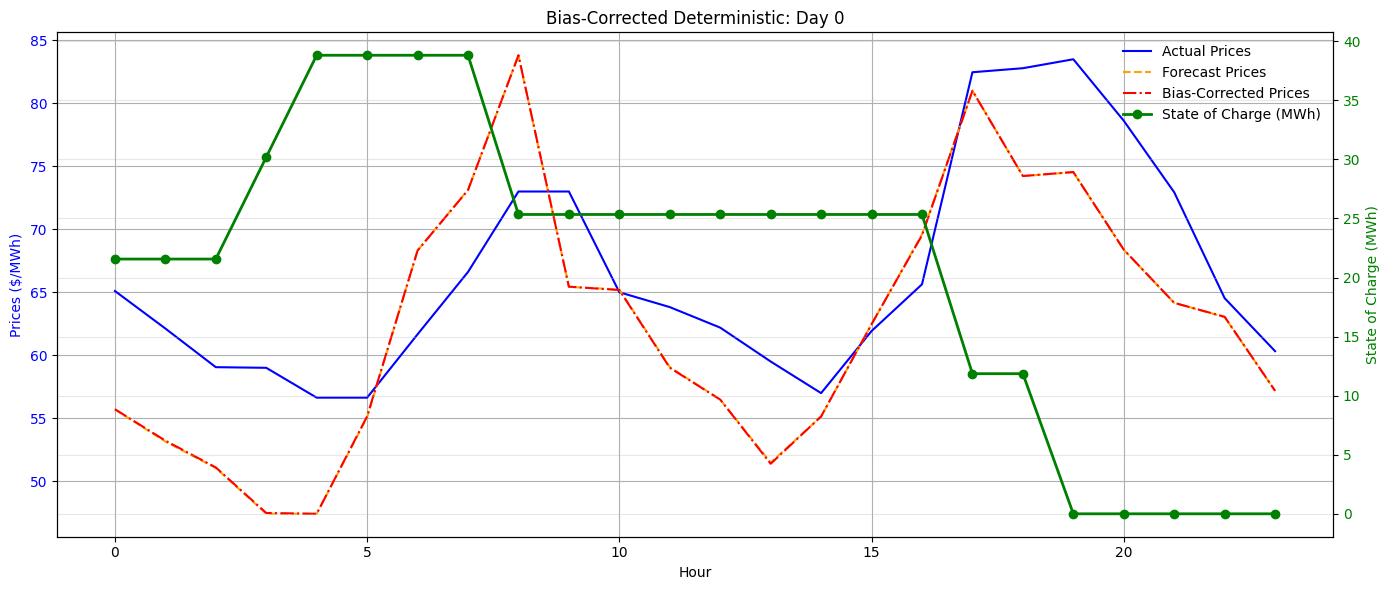

In [12]:
plot_prices_and_soc(
    day_info=day_info_bias_det,
    result=results_bias_det,
    batterydetails=batterydetails,
    price_bias=price_bias,
    day_idx=0,
    title="Bias-Corrected Deterministic: Day 0",
)

In [13]:
eval_df_bias_det = build_eval_df(
    day_info=day_info_bias_det,
    result=results_bias_det,
    batterydetails=batterydetails,
    price_bias=price_bias,
    demand_bias=demand_bias,
    method_name="bias_corrected_det",
    dt_hours=1.0,
)

In [14]:
# eval_df_bias_det["profit_step"] = (eval_df_bias_det["discharge_MW"] - eval_df_bias_det["charge_MW"]) * eval_df_bias_det["prices_actual"] * 1
total_profit = eval_df_bias_det["profit_step"].sum()

print("Total arbitrage profit:", total_profit)

Total arbitrage profit: 1221.8728999999998
